<a href="https://colab.research.google.com/github/pedrovsbenevides/mvp_ml_pucrio/blob/main/MVP_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** Pedro Benevides

**Matrícula:** 4052026000134

**Data:** 04/07/2026  

**Dataset:** [Bike Sharing](https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset)

**Tipo de problema:** Regressão

# 1. Definição do problema


## 1.1 Descrição do problema

Descreva, em linguagem simples, o problema que será resolvido.

**O que incluir:**
- Qual é o contexto do problema?
- Qual decisão, previsão, classificação, agrupamento ou análise o modelo deve apoiar?
- Quem seria o usuário ou interessado nessa solução?
- Por que esse problema é relevante?


---




- Qual é o contexto do problema?
> As aplicações de aluguel de bikes tem se popularizado no novo formato em que o usuário pode alugar em um local e entregar a bike em alguma outro ponto, é uma alternativa de locomoção que apoia a mobilidade urbana. Ao contrário dos outros meios de transporte, os dados dos usuários que alugam bikes tem uma maior disponibilidade para serem monitorados.
- Qual decisão, previsão, classificação, agrupamento ou análise o modelo deve apoiar?
> O modelo deve apoiar na previsão de demanda para o aluguel de bikes através de regressão em dados temporais
- Quem seria o usuário ou interessado nessa solução?
> Negócios voltados para o nicho de aluguel de bikes e/ou organizações que prestam serviços de apoio a esse meio de transporte e lazer
- Por que esse problema é relevante?
> Hoje existe grande interesse nos sistemas que disponibilizam bikes para aluguel devido ao seu papel importante em questões de tráfego. O monitoramento desses dados tem o potencial de apoiar decisões ambientais, saúde e mobilidade urbana

## 1.2 Objetivo do MVP

Escreva o objetivo do MVP em uma ou duas frases.

---



**Objetivo deste trabalho:**  
> O objetivo deste MVP é construir e avaliar modelos de Machine Learning para prever demanda de aluguel de bikes a partir de dados temporais e climáticos, comparando uma abordagem baseline com modelos candidatos e discutindo suas limitações e melhorias.

## 1.3 Tipo de problema

Indique o tipo de problema e justifique.

- **Classificação:** prever uma classe/categoria.
- **Regressão:** prever um valor numérico contínuo.
- **Clusterização:** agrupar exemplos similares sem rótulo conhecido.
- **Séries temporais / forecasting:** prever valores futuros respeitando a ordem temporal.



---




- Tipo escolhido:
> **Regressão:** prever um valor numérico contínuo.
- Justificativa:
> Apesar de aparentar ser um problema de séries temporais/forecasting, muitas variáveis exógenas (clima, estação, feriado, sensação térmica) são relevantes para o objeto observado (aluguel de bicicletas), indicando uma melhor modelagem como um problema de regressão com dependência temporal para previsão da demanda de bicicletas

## 1.4 Premissas, hipóteses e critérios de sucesso

Liste as principais hipóteses e como você pretende verificar se o MVP foi bem-sucedido.

**Hipóteses iniciais:**
1. _Hipótese 1._
2. _Hipótese 2._
3. _Hipótese 3._

**Critérios de sucesso:**
- Métrica principal: _ex.: F1-score, RMSE, MAE, silhouette, MAPE etc._
- Resultado mínimo esperado: _ex.: superar o baseline em pelo menos X%._
- Restrição prática: _ex.: tempo de treino, interpretabilidade, simplicidade, custo computacional._



---




**Hipóteses iniciais:**
1. _A estação do ano tem forte influência, sendo o verão a estação com maior quantidade de alugéis_
2. _A sensação térmica e condição climática também possuem forte influência na variável alvo_
3. _Deve ser possivel identificar alguma característica cíclica da demanda_

**Critérios de sucesso:**
- Métrica principal: _RMSE, para interpretar o erro de previsão da demanda em unidades reais de bicicletas alugadas._
- Resultado mínimo esperado: _Uma redução do RMSE em comparação ao baseline de pelo menos 40%._

# 2. Ambiente, bibliotecas e reprodutibilidade

Esta seção deve reunir as importações, configuração de seed e informações básicas do ambiente.

**O que incluir:**
- bibliotecas utilizadas;
- seed fixa para reprodutibilidade;
- observações sobre GPU/CPU, quando relevante;
- versões de bibliotecas, se houver dependências específicas.


---



In [1]:
# === Setup básico e reprodutibilidade ===
import os
import sys
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import ElasticNet, Ridge, Lasso, LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor # Algoritmo XGBoost
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import randint, uniform

from sklearn.feature_selection import RFECV # para a Eliminação Recursiva de Atributos

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
np.set_printoptions(precision=3)

print("Python:", sys.version.split()[0])
print("Seed:", SEED)

Python: 3.12.13
Seed: 42


## 2.1 Funções auxiliares

In [2]:
def evaluate_regression(y_true, y_pred, train_time=0):
    """Calcula métricas básicas para regressão."""
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred),
        "train_time_s" : round(train_time, 3)
    }

def show_results_table(results_dict):
    """Exibe resultados como DataFrame ordenável."""
    return pd.DataFrame(results_dict).T

# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

Descreva a base escolhida.

**O que incluir:**
- nome do dataset;
- link da fonte;
- por que esse dataset foi escolhido;
- quais restrições ou condições foram consideradas;
- se há questões de ética, privacidade, confidencialidade ou licença.



---





O Dataset escolhido é o [Bike Sharing Dataset da UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset). Contém registros diários de aluguel de bicicletas do sistema Capital Bikeshare entre 2011 e 2012, com variáveis climáticas, sazonais e temporais.

- Esse dataset foi escolhido pela possibilidade de investigar as interessantes dinâmicas entre as suas variavéis, como a exploração da granularidade de dia e horario, bem como o clima e a estação do ano.
- O dataset contém dados públicos e disponibilizados sob licença CC BY 4.0, permitindo uso, compartilhamento e adaptação desde que a fonte seja devidamente creditada.

## 3.2 Carga dos dados

In [3]:
# url = "https://archive.ics.uci.edu/static/public/275/data.csv" UCI Dataset URL
url = "https://raw.githubusercontent.com/pedrovsbenevides/mvp_ml_pucrio/refs/heads/main/hour.csv"
df = pd.read_csv(url)
df.head(10)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
5,6,2011-01-01,1,0,1,5,0,6,0,2,0.24,0.2576,0.75,0.0896,0,1,1
6,7,2011-01-01,1,0,1,6,0,6,0,1,0.22,0.2727,0.80,0.0000,2,0,2
7,8,2011-01-01,1,0,1,7,0,6,0,1,0.20,0.2576,0.86,0.0000,1,2,3
8,9,2011-01-01,1,0,1,8,0,6,0,1,0.24,0.2879,0.75,0.0000,1,7,8
9,10,2011-01-01,1,0,1,9,0,6,0,1,0.32,0.3485,0.76,0.0000,8,6,14


## 3.3 Visão geral do dataset

Antes de modelar, apresente uma visão geral da base.

**O que incluir:**
- quantidade de linhas e colunas;
- tipos dos atributos;
- valores ausentes;
- duplicatas;
- possíveis colunas de ID, data ou variáveis que não devem entrar no modelo;
- descrição do target, se houver.



---




- 3.3.1 Quantidade de linhas e colunas;
- 3.3.2 Tipos dos atributos;
- 3.3.3 Valores ausentes;
- 3.3.4 Duplicatas;
- 3.3.5 Colunas de ID, data e variáveis que não devem entrar no modelo;
- 3.3.6 Descrição do target

In [4]:
display(df.sample(5, random_state=SEED))

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
12830,12831,2012-06-23,3,1,6,19,0,6,0,1,0.80,0.6970,0.27,0.1940,185,240,425
8688,8689,2012-01-02,1,1,1,20,1,1,0,1,0.24,0.2273,0.41,0.2239,5,83,88
7091,7092,2011-10-28,4,0,10,2,0,5,1,1,0.32,0.3030,0.66,0.2836,1,3,4
12230,12231,2012-05-29,2,1,5,19,0,2,1,1,0.78,0.7121,0.52,0.3582,69,457,526
431,432,2011-01-20,1,0,1,0,0,4,1,1,0.26,0.2273,0.56,0.3881,5,8,13


### 3.3.1 Quantidade de linhas e colunas

In [5]:
print("Formato do dataset:", df.shape)

Formato do dataset: (17379, 17)


### 3.3.2 Tipos dos atributos

In [6]:
print("\nTipos de dados:")
display(df.dtypes.to_frame("tipo"))


Tipos de dados:


,tipo
instant,int64
dteday,object
season,int64
yr,int64
mnth,int64
hr,int64
holiday,int64
weekday,int64
workingday,int64
weathersit,int64


### 3.3.3 Valores ausentes

In [7]:
print("\nValores ausentes por coluna:")
display(df.isna().sum().to_frame("Ausentes"))


Valores ausentes por coluna:


,Ausentes
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


### 3.3.4 Duplicatas

In [8]:
print("\nDuplicatas:", df.duplicated().sum())


Duplicatas: 0


### 3.3.5 Colunas de ID, data e variáveis que não devem entrar no modelo

| Coluna     | Tipo     | Descrição                                  |
| ---------- | -------- | ------------------------------------------ |
| instant    | ID       | Índice sequencial                          |
| dteday     | Data     | Data do registro                           |
| casual     | Outro    | Quantidade de usuários pontuais            |
| registered | Outro    | Quantidade de usuários registrados         |

### 3.3.6 Descrição do target

| Coluna     | Tipo     | Descrição                                         |
| ---------- | -------- | ------------------------------------------        |
| cnt        | Target   | Quantidade total de alugueis (casual+registered)  |

## 3.4 Dicionário de dados

| Coluna     | Tipo       | Descrição                                                      | Será usada no modelo? | Observações                                                           |
| ---------- | ---------- | -------------------------------------------------------------- | --------------------- | --------------------------------------------------------------------- |
| instant    | numérica   | Índice sequencial do registro                                  | não                   | Apenas identificador, sem relevância preditiva                        |
| dteday     | data       | Data do registro                                               | não                   | Será decomposta e utilizada para gerar feature temporal do dia do mês |
| season     | categórica | Estação do ano (1: inverno, 2: primavera, 3: verão, 4: outono) | sim                   | Avaliar impacto das estações no comportamento da demanda              |
| yr         | categórica | Ano da observação (0: 2011, 1: 2012)                           | sim                   | Pode capturar crescimento da adoção do serviço ao longo do tempo      |
| mnth       | categórica | Mês do ano (1 a 12)                                            | sim                   | Sazonalidade mensal                                                   |
| hr         | categórica | Hora do dia (0 a 23)                                           | sim                   | Avaliar impacto na demanda, identificar horários de pico              |
| holiday    | categórica | Indica se o dia é feriado                                      | sim                   | Avaliar impacto dos feriados no uso das bicicletas                    |
| weekday    | categórica | Dia da semana (0: Domingo a 6: Sábado)                                                 | sim                   | Avaliar diferenças entre dias úteis e finais de semana                |
| workingday | categórica | Indica se o dia é útil ( 1: dia úti; 0: fim de semana ou feriado)                                         | sim                   | Avaliar deslocamento da demanda                                       |
| weathersit | categórica | Condição climática (1: céu limpo, poucas nuvens, parcialmente nublado; 2: névoa + nublado, névoa + nuvens dispersas, névoa leve; 3: neve leve, chuva leve + trovoadas + nuvens dispersas, chuva leve + nuvens dispersas; 4: chuva forte + granizo + trovoadas + névoa, neve + neblina)                              | sim                   | Avaliar influencia do clima na quantidade de aluguéis                 |
| temp       | numérica   | Temperatura normalizada em Celsius                             | sim                   | Avaliar influencia de váriaveis climáticas no impacto da demanda      |
| atemp      | numérica   | Sensação térmica normalizada em Celsius                        | sim                   | Avaliar influencia de váriaveis climáticas no impacto da demanda      |
| hum        | numérica   | Umidade relativa normalizada; Valores divididos por 100 (valor máximo)                               | sim                   | Avaliar influencia de váriaveis climáticas no impacto da demanda      |
| windspeed  | numérica   | Velocidade do vento normalizada; Valores divididos por 67 (valor máximo)                                | sim                   | Avaliar influencia de váriaveis climáticas no impacto da demanda      |
| casual     | numérica   | Quantidade de usuários casuais                                 | não                   | Vazamento de informação pois compõe a variável alvo                   |
| registered | numérica   | Quantidade de usuários registrados                             | não                   | Vazamento de informação pois compõe a variável alvo                   |
| cnt        | alvo       | Quantidade total de bicicletas alugadas                        | alvo                  | Variável alvo para previsão, composta por ambos tipo de usuários (casual+registered)                                          |



# 4. Análise exploratória dos dados

A análise exploratória deve ser objetiva e conectada ao problema.

**O que incluir:**
- distribuição do target;
- distribuição de variáveis importantes;
- relação entre variáveis e target;
- identificação de desbalanceamento, outliers ou padrões relevantes;
- hipóteses que surgem a partir dos dados.

---



## 4.1 Distribuição do Target

In [9]:
TARGET = "cnt"

if TARGET is not None and TARGET in df.columns:
    print("Distribuição do target:")
    display(df[TARGET].value_counts(dropna=False, sort=True).to_frame("contagem"))
    display((df[TARGET].value_counts(normalize=True, dropna=False, sort=True) * 100).round(2).to_frame("percentual"))


Distribuição do target:


,contagem
cnt,
5,260
6,236
4,231
3,224
2,208
...,...
938,1
826,1
963,1


,percentual
cnt,
5,1.50
6,1.36
4,1.33
3,1.29
2,1.20
...,...
938,0.01
826,0.01
963,0.01


**Distribuição do target:**
> A análise tabular da distribuição do target indica que a ocorrencia de valores menores (<= 5) é mais frequente para o problema, os valores maiores (>= 600) podem representar outliers.

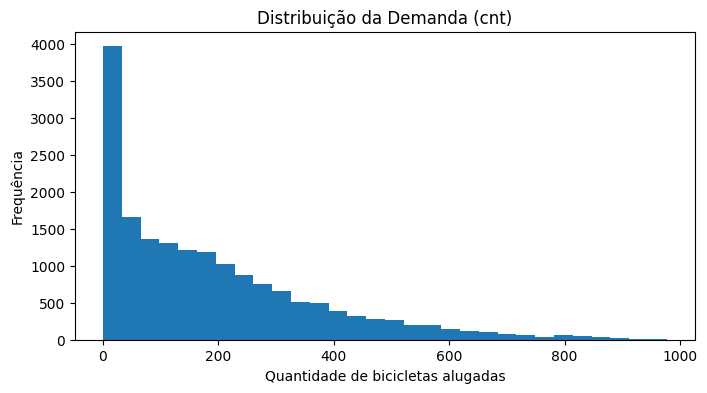

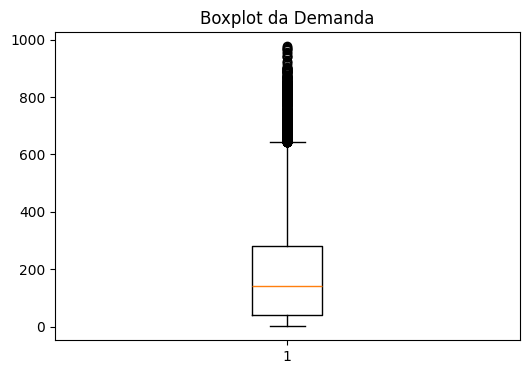

In [10]:
# Histograma
plt.figure(figsize=(8,4))
plt.hist(df[TARGET], bins=30)
plt.title(f"Distribuição da Demanda ({TARGET})")
plt.xlabel("Quantidade de bicicletas alugadas")
plt.ylabel("Frequência")
plt.show()

# Boxplot
plt.figure(figsize=(6,4))
plt.boxplot(df[TARGET])
plt.title("Boxplot da Demanda")
plt.show()

**Distribuição do target:**
> As análises gráficas confirmam a análise tabular, em que a maior concentração de registros de demanda está presente nos menores valores. O Boxplot auxilia na identificação de outliers que começam a aparecer proximos ao valor de 600.

### 4.1.1 Hipóteses iniciais

As hipoteses iniciais giram em torno de que os valores mais frequentes estão relacionados ao uso diário de bicicletas, mais associados aos horarios de ida ao trabalho e retorno para casa (próximo as 8h e as 17h). Além disso, o clima e sensação térmica devem ser grande influência, onde temperaturas e climas mais agradavéis devem influenciar maior demanda, para além das pessoas que utilizam como meio de transporte principal, enquanto climas chuvosos e temperaturas mais baixas devem reduzir essa demanda. Os ciclos de demanda podem girar em torno das estações do ano, que influenciam diretamente nessas condições climáticas.

## 4.2 Distribuição de variáveis

### 4.2.1 atemp

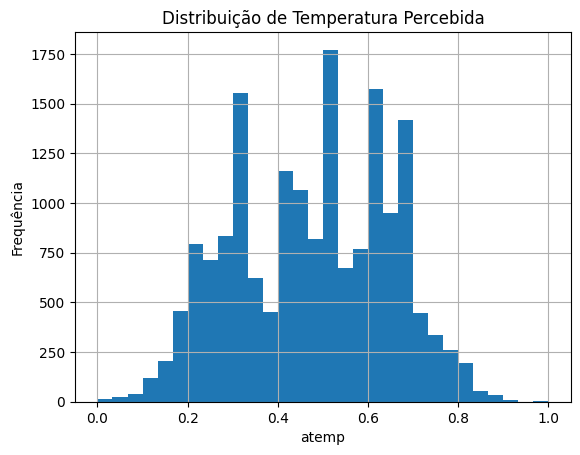

In [11]:
df['atemp'].hist(bins=30)
plt.title("Distribuição de Temperatura Percebida")
plt.xlabel('atemp')
plt.ylabel("Frequência")
plt.show()

**atemp:**
> A variável atemp (temperatura percebida) apresentou 4 picos em seu histograma, distribuidos entre os valores de 0,3 a 0,75. Esses diferentes picos podem estar associados a períodos de temperatura mais confortável durante cada uma das estações do ano.

### 4.2.2 season

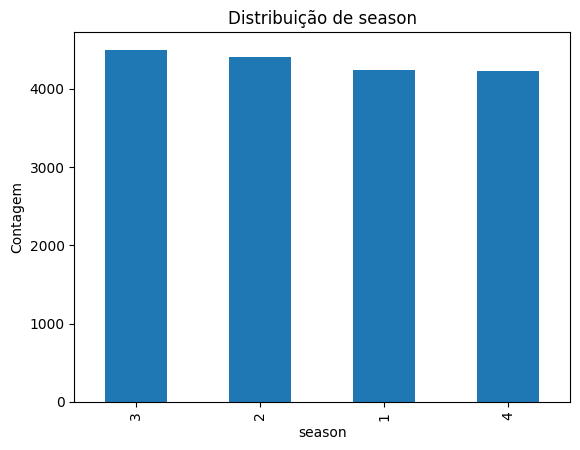

In [12]:
df['season'].value_counts().plot(kind="bar")
plt.title(f"Distribuição de {'season'}")
plt.xlabel('season')
plt.ylabel("Contagem")
plt.show()

**season:**
> Ocorrências no Verão possuem leve destaque frente as demais estações.

### 4.2.3 weathersit

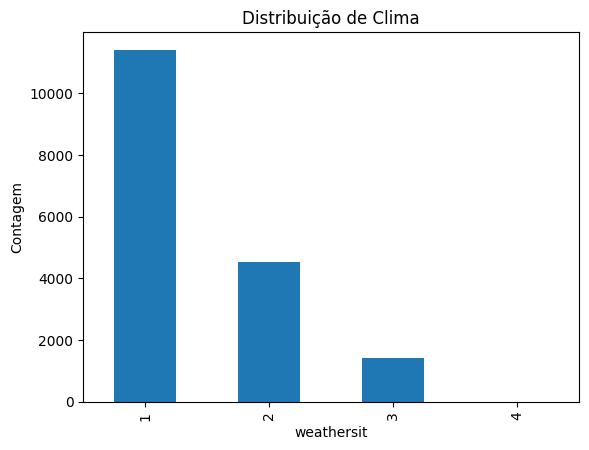

In [13]:
df['weathersit'].value_counts().plot(kind="bar")
plt.title(f"Distribuição de Clima")
plt.xlabel('weathersit')
plt.ylabel("Contagem")
plt.show()

**weathersit:**
> Em sintese as condições climáticas podem ser lidas como:

> 1.   Limpo
> 2.   Parcialmente Nublado
> 3.   Chuva/Neve Leves
> 4.   Chuva/Neve Fortes

> Assim, temos uma representação de ocorrências da demanda muito baixa em condições de clima mais intensos, com maior representação para as faixas de clima mais confortaveis.

### 4.2.4 workingday

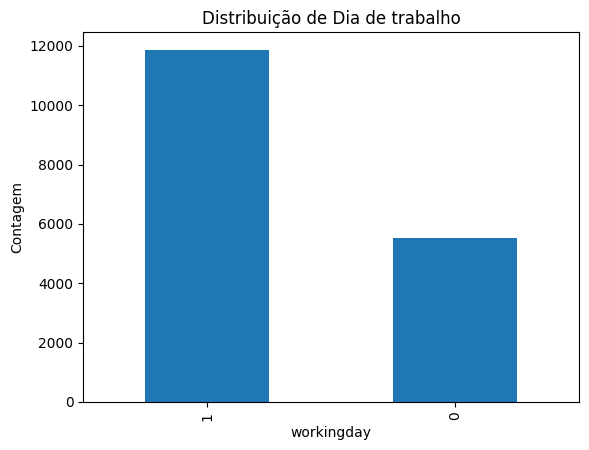

In [14]:
df['workingday'].value_counts().plot(kind="bar")
plt.title(f"Distribuição de Dia de trabalho")
plt.xlabel('workingday')
plt.ylabel("Contagem")
plt.show()

**workingday:**
> Identificação de maior presença de demanda em dia de trabalho.

## 4.2 Relação entre variáveis e target

>

### 4.2.1 hr x cnt

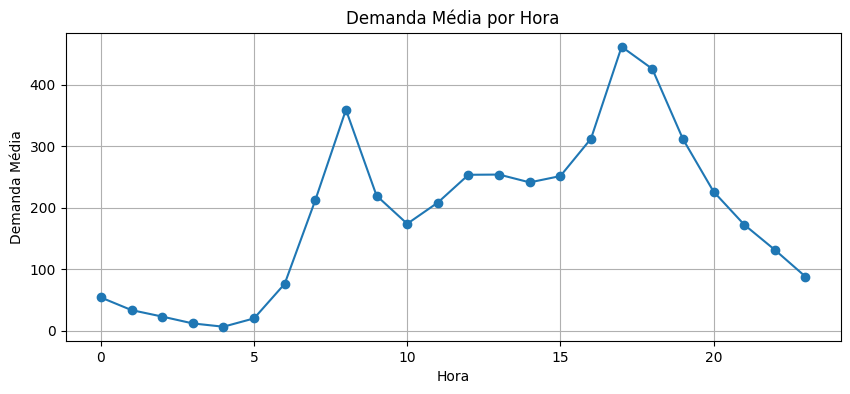

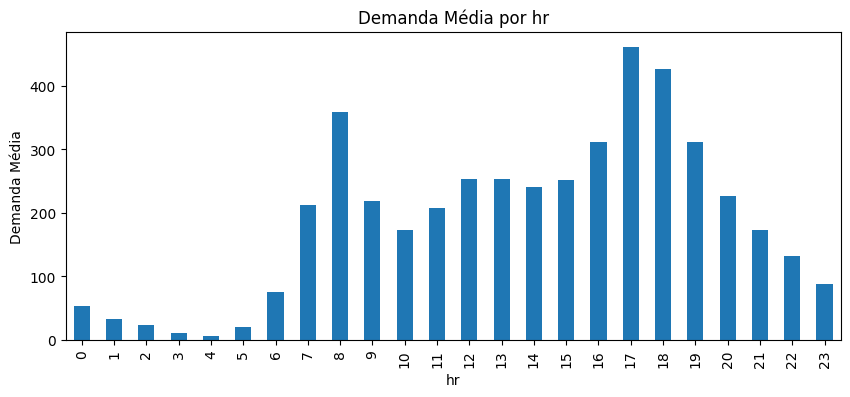

In [15]:
# Line
hourly_mean = df.groupby("hr")["cnt"].mean()
plt.figure(figsize=(10,4))
plt.plot(hourly_mean.index, hourly_mean.values, marker="o")
plt.title("Demanda Média por Hora")
plt.xlabel("Hora")
plt.ylabel("Demanda Média")
plt.grid(True)
plt.show()

# Bar
plt.figure(figsize=(10,4))
plt.title("Demanda Média por hr")
plt.xlabel("hr")
plt.ylabel("Demanda Média")
plt.grid(True)
hourly_mean = hourly_mean.plot(kind="bar")

**hr x cnt:**
> Observa-se forte influência da hora do dia sobre a demanda, confirmando a hipótese de picos associados aos horários de deslocamento para trabalho e retorno para casa.

### 4.2.2 atemp x cnt

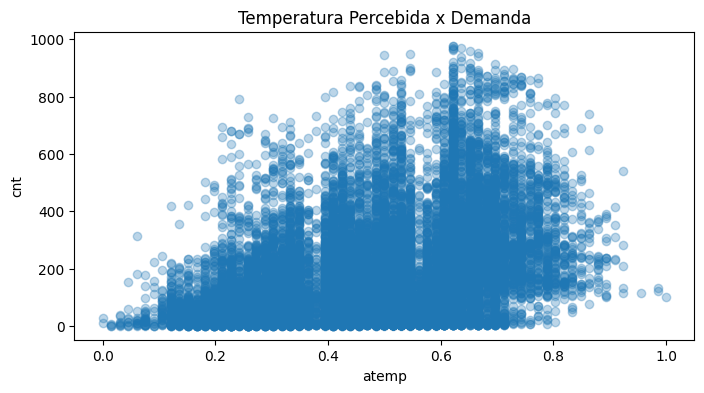

In [16]:
plt.figure(figsize=(8,4))
plt.scatter(df["atemp"], df["cnt"], alpha=0.3)
plt.title("Temperatura Percebida x Demanda")
plt.xlabel("atemp")
plt.ylabel("cnt")
plt.show()

**atemp x cnt:**
> A correlação de 'atemp' com a variável target é confirmada através do gráfico de dispersão. Confirma-se uma correlação positiva em que a variavel target cresce enquanto a temperatura percebida aumenta até um limite confortável, sem concentração nas faixas mais baixas e de temperaturas extremas, estabilizando ou reduzindo nessas situações.

### 4.2.3 season x cnt

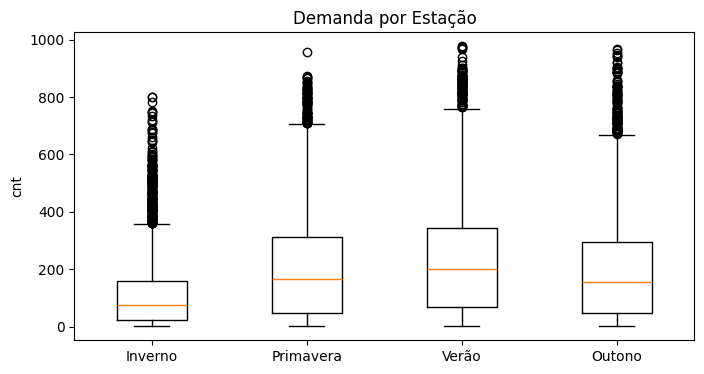

In [17]:
season_data = [
    df[df["season"] == 1]["cnt"],
    df[df["season"] == 2]["cnt"],
    df[df["season"] == 3]["cnt"],
    df[df["season"] == 4]["cnt"]
]
plt.figure(figsize=(8,4))
plt.boxplot(season_data,
            labels=["Inverno","Primavera","Verão","Outono"])
plt.title("Demanda por Estação")
plt.ylabel("cnt")
plt.show()

**season x cnt:**
> Confirma-se a maior ocorrência de demanda no verão porém com uma distribuição equilibrada entre todas as estações.

### 4.2.4 weathersit x cnt

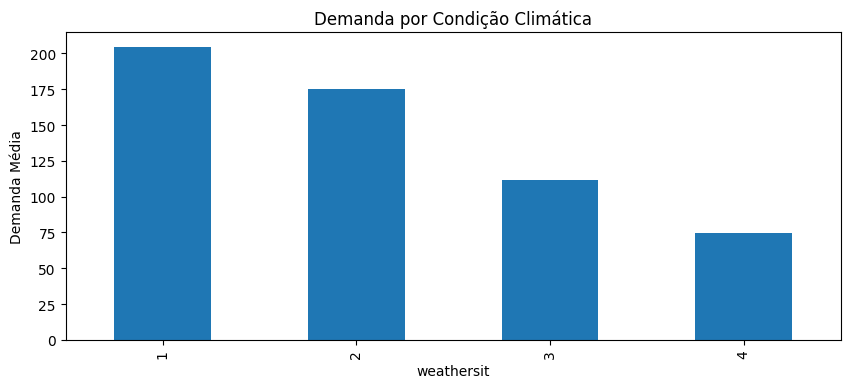

In [18]:
weather_data = df.groupby("weathersit")["cnt"].mean()
plt.figure(figsize=(10,4))
plt.title("Demanda por Condição Climática")
plt.xlabel("weathersit")
plt.ylabel("Demanda Média")
weather_data = weather_data.plot(kind='bar')

**weathersit x cnt:**
> A demanda não é zerada frente a condições climáticas mais intensas, porém confirma a suspeita de possuir a menor das ocorrências de demanda.

### 4.2.5 Análise temporal do target

#### 4.2.5.1 Diária

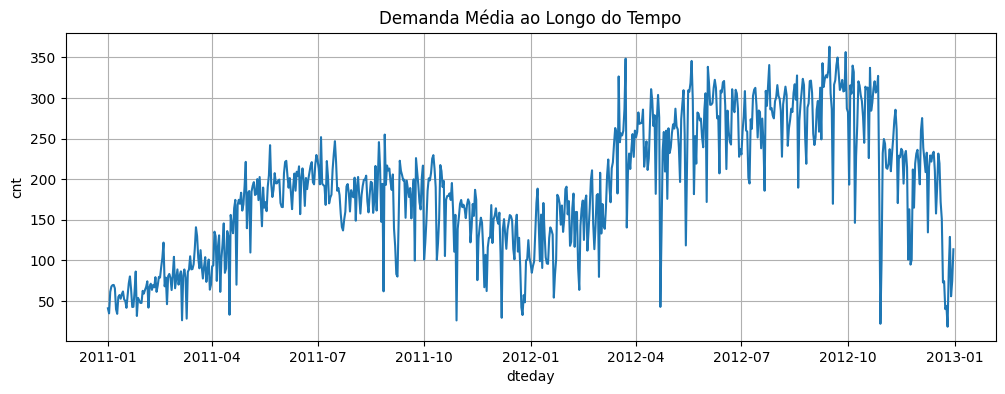

In [19]:
df['dteday'] = pd.to_datetime(df['dteday'])

daily_cnt = df.groupby("dteday")["cnt"].mean()
plt.figure(figsize=(12,4))
plt.plot(daily_cnt.index, daily_cnt.values)
plt.title("Demanda Média ao Longo do Tempo")
plt.xlabel("dteday")
plt.ylabel("cnt")
plt.grid(True)
plt.show()

#### 4.2.5.2 Semanal

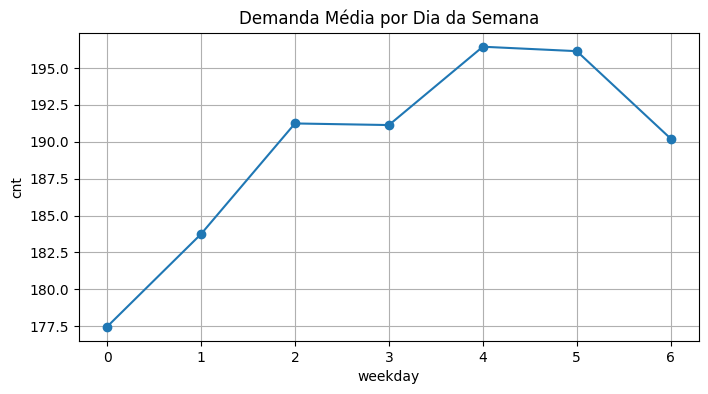

In [20]:
weekly_cnt = df.groupby("weekday")["cnt"].mean()

plt.figure(figsize=(8,4))

plt.plot(weekly_cnt.index,
         weekly_cnt.values,
         marker="o")

plt.title("Demanda Média por Dia da Semana")
plt.xlabel("weekday")
plt.ylabel("cnt")

plt.grid(True)

plt.show()

#### 4.2.5.3 Mensal

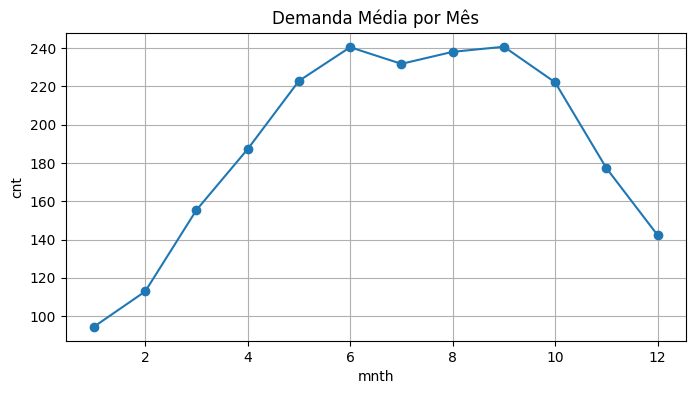

In [21]:
monthly_cnt = df.groupby("mnth")["cnt"].mean()

plt.figure(figsize=(8,4))

plt.plot(monthly_cnt.index,
         monthly_cnt.values,
         marker="o")

plt.title("Demanda Média por Mês")
plt.xlabel("mnth")
plt.ylabel("cnt")

plt.grid(True)

plt.show()

#### 4.2.5.4 Anual

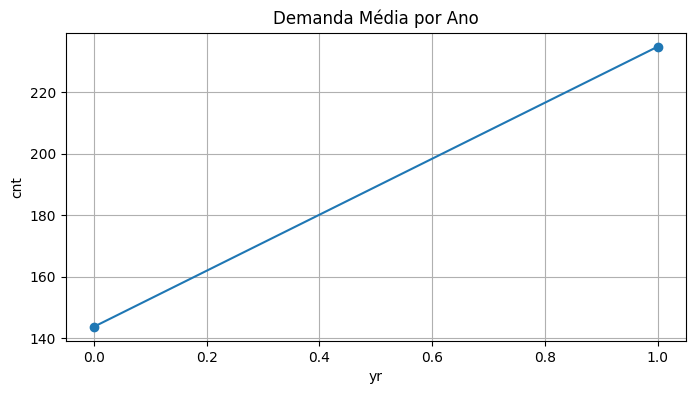

In [22]:
monthly_cnt = df.groupby("yr")["cnt"].mean()

plt.figure(figsize=(8,4))

plt.plot(monthly_cnt.index,
         monthly_cnt.values,
         marker="o")

plt.title("Demanda Média por Ano")
plt.xlabel("yr")
plt.ylabel("cnt")

plt.grid(True)

plt.show()

**Análise temporal do target:**
> A análise temporal em diferentes níveis de tempo permitiu a identificação de uma tendência de crescimento entre os dois anos presentes no dataset (0: 2011, 1: 2012), além da identificação de padrões cíclicos: ao se observar a série histórica diária percebe-se um crescimento da demanda entre os meses 1 a 7, seguida de uma queda até a chegada do próximo mês 1 no próximo ano. Esse padrão pode ser confirmado ao se analisar a serie histórica da média mensal.

> De forma complementar percebemos a demanda ciclica entre os dias da semana, que naturalmente se repetem ao longo dos meses, com destaque para os dias que representam as jornadas de trabalho mais comuns (1: segunda a 5: sexta)

## 4.3 Síntese da análise exploratória

> A análise exploratória permitiu identificar fatores temporais e climáticos como os principais influenciadores da demanda de bicicletas. A variável de temperatura percebida (`atemp`) apresentou distribuição multimodal, com quatro picos distribuídos aproximadamente entre os valores normalizados de 0,3 e 0,75, sugerindo diferentes regimes climáticos associados às estações do ano. A análise da relação entre temperatura percebida e demanda confirmou uma correlação positiva, indicando aumento da utilização das bicicletas à medida que a temperatura se aproxima de faixas mais confortáveis, com estabilização ou redução da demanda em condições de frio ou calor extremos.

> As condições climáticas também demonstraram impacto relevante sobre a variável alvo. Observou-se menor volume de locações em situações climáticas adversas, embora a demanda não seja completamente interrompida nessas condições. Por outro lado, as maiores concentrações de uso ocorreram em cenários climáticos mais favoráveis.

> A análise das variáveis temporais revelou padrões consistentes de comportamento. Os dias úteis apresentaram maior volume de demanda em comparação aos finais de semana e feriados, enquanto a variável hora do dia evidenciou dois picos característicos de utilização, associados aos horários de deslocamento para o trabalho e retorno para casa. Em relação às estações do ano, o verão apresentou ligeiro destaque em volume de demanda, embora a distribuição de ocorrências tenha se mostrado relativamente equilibrada entre todas as estações.

> A avaliação da série temporal revelou uma tendência de crescimento da demanda entre os anos de 2011 e 2012, além de padrões sazonais recorrentes. Observou-se crescimento gradual da demanda entre os primeiros meses do ano e o meio do ano, seguido por redução nos meses subsequentes, comportamento que se repetiu ao longo do período analisado. Padrões cíclicos também foram identificados na análise dos dias da semana, com maior demanda concentrada nos dias úteis.

> Diante desses resultados, as variáveis temporais cíclicas (`hr`, `weekday` e `mnth`) deverão ser transformadas em pares seno e cosseno. Essa abordagem permite representar adequadamente a natureza circular dessas variáveis, preservando a proximidade entre períodos consecutivos, como 23h e 0h, dezembro e janeiro ou domingo e segunda-feira. Sem essa transformação, os modelos poderiam interpretar incorretamente essas categorias como extremos opostos da escala numérica, prejudicando a captura dos padrões sazonais e periódicos identificados durante a análise exploratória._


# 5. Preparação dos dados e divisão treino/teste

Nesta etapa, defina claramente quais colunas serão utilizadas, qual é o target e como os dados serão divididos.

**O que incluir:**
- separação entre features e target;
- remoção de colunas que não devem ser usadas;
- divisão treino/teste;
- validação, quando aplicável;
- justificativa para a divisão escolhida.


In [23]:
# === Preparação === #

# Extração da informação de dia do mês a partir da coluna dteday
df['monthday'] = df['dteday'].dt.day

# Variáveis que possuem periodicidade natural e contínua:
# Tratamento da informação ciclica relacionado a variavel hr (hora do dia)
df["hr_sin"] = np.sin(2 * np.pi * df["hr"] / 24)
df["hr_cos"] = np.cos(2 * np.pi * df["hr"] / 24)

# Tratamento da informação ciclica relacionado a variavel weekday (dia da semana)
df["weekday_sin"] = np.sin(2 * np.pi * df["weekday"] / 7)
df["weekday_cos"] = np.cos(2 * np.pi * df["weekday"] / 7)

# Tratamento da informação ciclica relacionado a variavel mnth (mês)
df["mnth_sin"] = np.sin(2 * np.pi * df["mnth"] / 12)
df["mnth_cos"] = np.cos(2 * np.pi * df["mnth"] / 12)


In [24]:
# === Configuração do problema === #

TARGET = "cnt"
PROBLEM_TYPE = "regressao"
ID_COLUMNS = ["instant"]
DROP_COLUMNS = ['dteday', 'hr', 'weekday', 'mnth', 'temp', 'casual', 'registered']

columns_to_exclude = set(ID_COLUMNS + DROP_COLUMNS)
columns_to_exclude.add(TARGET)

original_features = [c for c in df.columns if c not in columns_to_exclude]
print("Atributos Originais:", original_features)

Atributos Originais: ['season', 'yr', 'holiday', 'workingday', 'weathersit', 'atemp', 'hum', 'windspeed', 'monthday', 'hr_sin', 'hr_cos', 'weekday_sin', 'weekday_cos', 'mnth_sin', 'mnth_cos']


In [25]:
# === Divisão dos dados para REGRESSAO com dependência temporal === #

DATE_COLUMN = "dteday"

df_sorted = df.sort_values(DATE_COLUMN).copy()
cutoff = int(len(df_sorted) * 0.8)
train_df = df_sorted.iloc[:cutoff]
test_df = df_sorted.iloc[cutoff:]

X_train = train_df[original_features].copy()
y_train = train_df[TARGET].copy()
X_test = test_df[original_features].copy()
y_test = test_df[TARGET].copy()

print("Treino:", X_train.shape, "| Teste:", X_test.shape)

X_train.columns

Treino: (13903, 15) | Teste: (3476, 15)


Index(['season', 'yr', 'holiday', 'workingday', 'weathersit', 'atemp', 'hum',
       'windspeed', 'monthday', 'hr_sin', 'hr_cos', 'weekday_sin',
       'weekday_cos', 'mnth_sin', 'mnth_cos'],
      dtype='object')

## 5.1 Justificativa da divisão

Explique por que a divisão escolhida é adequada.

**O que comentar:**
- Por que usar holdout, validação cruzada ou divisão temporal?
- A proporção treino/teste faz sentido para o tamanho do dataset?
- Foi necessário estratificar as classes?
- Como a divisão evita vazamento de dados?


---




**Resposta:**
> Foi adotada uma divisão temporal de 80% dos registros para treinamento e 20% para teste. Com um total de 17.379 registros a divisão refletiu para treino (80%) = 13.903 observações e para teste (20%) = 3476 observações.

> Essa estratégia buscou equilibrar dois objetivos: disponibilizar uma quantidade suficiente de dados para o aprendizado dos padrões de demanda e reservar um conjunto representativo para avaliação da capacidade de generalização do modelo.

> Como o dataset possui natureza temporal, a separação foi realizada por holdout preservando a ordem cronológica das observações, evitando que informações futuras fossem utilizadas durante o treinamento. Dessa forma, o conjunto de teste simula um cenário real de previsão, no qual o modelo é aplicado a períodos posteriores aos observados durante seu treinamento.

# 6. Pré-processamento e pipeline

Crie uma sequência reprodutível de tratamento dos dados.

**Possíveis etapas:**
- imputação de valores ausentes;
- normalização ou padronização;
- encoding de variáveis categóricas;
- seleção de atributos;
- engenharia de atributos;
- tratamento de texto, imagem ou séries temporais, quando aplicável.



---





**Etapas adotadas:**
- Padronização;
- Seleção de atributos;

## 6.1 Pré-processamento

In [26]:
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()

numeric_pipe = Pipeline(steps=[
    ("scaler", StandardScaler())
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_cols)
], remainder="drop")

print("Colunas numéricas:", num_cols)

Colunas numéricas: ['season', 'yr', 'holiday', 'workingday', 'weathersit', 'atemp', 'hum', 'windspeed', 'monthday', 'hr_sin', 'hr_cos', 'weekday_sin', 'weekday_cos', 'mnth_sin', 'mnth_cos']


## 6.2 Seleção de Atributos

In [27]:
feat_selection = {
    "ImportanciaAtributos": ExtraTreesRegressor(random_state=SEED, n_jobs=1), # modelos baseados em árvores não são sensiveis a diferenças de escala númerica

    "EliminacaoRecursiva": Pipeline(steps=[
      ("preprocess", preprocess),
      ("selector", RFECV(
          estimator=ElasticNet(random_state=SEED),
          cv=TimeSeriesSplit(n_splits=6),
          scoring="neg_root_mean_squared_error"
        ))
    ])
}

### 6.2.1 Eliminação Recursiva de Atributos com ElasticNet

In [28]:
feat_selection['EliminacaoRecursiva'].fit(X_train, y_train)
fit_eliminacao_recursiva = feat_selection['EliminacaoRecursiva'].named_steps["selector"]

ranking = pd.Series(
    fit_eliminacao_recursiva.ranking_,
    index=X_train.columns
).sort_values(ascending=True)

print("\nQtd de melhores Atributos: %d" % fit_eliminacao_recursiva.n_features_)
print("\nNomes dos Atributos Selecionados: %s" % fit_eliminacao_recursiva.get_feature_names_out(input_features=original_features))
print("\nRanking de atributos:\n", ranking)


Qtd de melhores Atributos: 8

Nomes dos Atributos Selecionados: ['season' 'yr' 'weathersit' 'atemp' 'hum' 'hr_sin' 'hr_cos' 'mnth_cos']

Ranking de atributos:
 season         1
yr             1
atemp          1
weathersit     1
hum            1
mnth_cos       1
hr_cos         1
hr_sin         1
mnth_sin       2
holiday        3
windspeed      4
workingday     5
weekday_sin    6
weekday_cos    7
monthday       8
dtype: int64


### 6.2.2 Importância de Atributos com ExtraTreesRegressor

In [29]:
fit_importancia_atributos = feat_selection['ImportanciaAtributos'].fit(X_train, y_train)

importances = pd.Series(
    fit_importancia_atributos.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importances)

hr_cos         0.284456
hr_sin         0.270433
atemp          0.107060
workingday     0.096863
yr             0.075667
mnth_cos       0.037762
season         0.034064
weathersit     0.026736
hum            0.018485
mnth_sin       0.012511
weekday_sin    0.009855
monthday       0.009462
windspeed      0.007668
weekday_cos    0.006862
holiday        0.002118
dtype: float64


### 6.2.3 Conclusão da Seleção de Atributos


**Conclusão:**  
> A seleção de atributos foi realizada por meio de RFECV utilizando ElasticNet e validação temporal com TimeSeriesSplit (n_splits=6). Nessa abordagem, foi identificada a quantidade de melhores atributos = 8 sendo eles: 'season', 'yr', 'atemp', 'weathersit', 'hum', 'hr_sin', 'hr_cos' e 'mnth_cos'.

> Além da indentificação da relevância do atributo 'workingday', as variáveis 'season', 'yr', 'atemp', 'hr_sin', 'hr_cos', 'mnth_cos' mantiveram sua importância consistente com o resultado da análise de importância de atributos via ExtraTreesRegressor, indicando que fatores temporais e climáticos exercem influência sobre a demanda de bicicletas. Por outro lado, variáveis como 'weathersit' e 'hum', não demonstraram contribuição significativa para o desempenho preditivo do modelo.

> Vale destacar que as variavéis *_sin e *_cos representam conjuntamente uma codificação cíclica temporal: a remoção de uma das componentes pode comprometer a representação da informação completa. Logo, a presença de 'mnth_cos' é suficiente para inclusão de 'mnth_sin', elas serão interpretadas em conjunto por sua dependência e lidas como um único atributo 'month'. A mesma leitura será aplicada para o contexto de 'hr'.

> Portanto, as variavéis selecionadas para seguir para a fase de treinamento foram: 'season', 'yr', 'atemp', 'hr_sin', 'hr_cos', 'mnth_sin', 'mnth_cos' e 'workingday', sendo esta última selecionada por apresentar maior importância frente as variáveis 'weathersit' e 'hum', mantendo dessa forma a quantidade de melhores atributos encontrada. Total de 8 colunas mas com uma interpretação de 6 atributos.

In [30]:
FEAT_SELECTED_COLUMNS = ['season', 'yr', 'atemp', 'hr_sin', 'hr_cos', 'mnth_sin', 'mnth_cos', 'workingday']

X_train = X_train[FEAT_SELECTED_COLUMNS].copy()
X_test = X_test[FEAT_SELECTED_COLUMNS].copy()

print("Treino:", X_train.shape, "| Teste:", X_test.shape)

num_cols = X_train.select_dtypes(include=np.number).columns.tolist()

numeric_pipe = Pipeline(steps=[
    ("scaler", StandardScaler())
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_cols)
], remainder="drop")

print("Colunas numéricas:", num_cols)

Treino: (13903, 8) | Teste: (3476, 8)
Colunas numéricas: ['season', 'yr', 'atemp', 'hr_sin', 'hr_cos', 'mnth_sin', 'mnth_cos', 'workingday']


## 6.3 Decisões de pré-processamento




Justifique as escolhas feitas.

**Exemplo de pontos a comentar:**
- Por que usei média/mediana/moda para imputação?
- Por que padronizei ou normalizei os dados?
- Quais variáveis foram removidas e por quê?
- Criei novas variáveis? Elas estariam disponíveis no momento real da previsão?



---



**Resposta:**
> Estratégias de imputação não foram necessárias, uma vez que a etapa da análise exploratória mostrou que não existem valores ausentes no dataset.

> Os dados foram padronizados pois como todas as colunas do dataset estão por padrão representadas numericamente se faz necessário aplicar o tratamento para a diferença de escala existente entre as variáveis contínuas, como temperatura percebida, umidade e velocidade do vento, e outras que são naturalmente categóricas mas foram codificadas numericamente, como estação do ano, dia da semana e condição climática. Dessa forma modelos sensíveis à escala dos atributos, não serão influenciados indevidamente por variáveis com valores numericamente maiores.

> As variáveis que possuem periodicidade natural e contínua relevantes para o problema — hora do dia, mês do ano e dia da semana —  foram transformadas em pares de variáveis seno e cosseno. Essas novas variaveis tem o objetivo de possibilitar aos modelos a interpretação da natureza cíclica, como as horas 23 e 0, os meses 12 e 1 ou os dias domingo e segunda-feira. Isso é algo que não seria possível através dessas variáveis com seus valores usuais devido distância na escala numérica.

> Seguindo o padrão adotado pelo dataset, que já possui colunas separadas para ano e mês, foi criada a variável monthday, representando o dia do mês extraído da coluna de data. Como essa informação está disponível no momento da realização da previsão, sua utilização não caracteriza vazamento de dados.

> Após a criação dos novos atributos, as variáveis originais correspondentes foram removidas para evitar redundância. A variável temp também foi removida por apresentar elevada redundância em relação à variável atemp, que representa a temperatura percebida. Por fim, as colunas 'casual' e 'registered' foram removidas pois compoem diretamente a variável alvo (cnt) e causariam um vazamento de informação para o conjunto de treino.

# 7. Baseline e modelos candidatos

Comece com uma solução simples para estabelecer referência.

**Obrigatório:**
- definir um baseline coerente;
- treinar pelo menos dois modelos/abordagens candidatas, quando aplicável;
- comparar os resultados de forma clara.


In [31]:
# === Definição de Baseline #
baseline = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DummyRegressor(strategy="median"))
    ])

# === Modelos Candidatos === #
candidates = {
    "ElasticNet": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", ElasticNet(random_state=SEED))
    ]),
    "KNNRegressor": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", KNeighborsRegressor(n_neighbors=4)) # k = 4 seguindo hipotese de agrupar pela quantidade de estações no ano
    ]),
    "XGBoost": XGBRegressor(objective="reg:squarederror", random_state=SEED) # objetive = regression with squared loss
}

## 7.1 Justificativa dos modelos




Explique por que os modelos escolhidos fazem sentido para este problema.

**O que comentar:**
- O baseline escolhido é coerente?
- Os modelos candidatos são adequados ao tipo e tamanho dos dados?
- Algum modelo exige escala, encoding ou tratamento específico?
- Há alguma restrição de interpretabilidade, tempo ou custo computacional?

---



**Resposta:**
> Partindo da análise exploratória, que identificou relações não lineares entre a demanda e variáveis temporais, climáticas e padrões sazonais, foram selecionados modelos capazes de capturar diferentes tipos de associação entre atributos e variável alvo.

> O baseline escolhido foi um clássico para problemas de regressão e será uma referência base para demonstar se os demais modelos estão realmente aprendendo. Além disso, um segundo "baseline" para referência será o modelo ElasticNet com o objetivo de validar as limitações de interpretações seguindo um padrão linear e justificar a complexidade de se utilizar os demais modelos.

> O KNNRegressor foi escolhido partindo da observação da relação season x cnt na análise exploratória que demonstrou distribuição equilibrada da variável alvo para todas as estações. Dessa forma, o modelo foi escolhido pensando na capacidade de realizar previsões com base na similaridade entre as observações em cada estação do ano. O valor de k = 4 foi escolhido partindo da hipotése de que os agrupamentos estarão relacionados as 4 estações do ano.

> O XGBoost foi selecionado por sua capacidade de modelar relações complexas e não lineares, além de apresentar desempenho consolidado em problemas tabulares de regressão.

> Apenas o XGBoost, baseado em árvore, não sofre impacto com as diferentes escalas entre os atributos. Para os demais modelos os atributos foram padronizados.



# 8. Treinamento e avaliação inicial

In [32]:
np.random.seed(SEED)
results = {}
trained_models = {}

# === Baseline === #
t0 = time.time()
baseline.fit(X_train, y_train)

train_time = time.time() - t0
y_pred = baseline.predict(X_test)

results["baseline"] = evaluate_regression(y_test, y_pred, train_time)
trained_models["baseline"] = baseline

# === Modelos Candidatos === #
for name, model in candidates.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = model.predict(X_test)
    results[name] = evaluate_regression(y_test, y_pred, train_time)

    trained_models[name] = model

# === Resultados Iniciais === #
show_results_table(results)

,MAE,RMSE,R2,train_time_s
baseline,182.239356,249.403558,-0.282103,0.018
ElasticNet,128.043320,182.302701,0.314979,0.013
KNNRegressor,78.598101,118.373322,0.711181,0.077
XGBoost,63.517712,94.710517,0.815110,0.344


## 8.1 Análise dos resultados iniciais


Interprete a tabela de resultados.

**Perguntas para responder:**
- O modelo superou o baseline?
- A métrica escolhida é suficiente para avaliar o problema?
- Algum modelo parece sofrer de underfitting?
- O tempo de treinamento é aceitável?
- O resultado faz sentido considerando a EDA?

---




**Resposta:**  
> Os modelos superaram o baseline em todas as métricas avaliadas. Os resultados do ElasticNet validam as limitações de uma abordagem linear e justificam a necessidade de modelos mais complexos. O KNNRegressor obteve melhora significativa na capacidade de explicação (R² = 0,711) e redução do erro (RMSE = 118,37), enquanto o XGBoost apresentou o melhor resultado, com RMSE = 94,71 e R² = 0,815.

> A avaliação utilizando principalmente RMSE e o R², de forma auxiliar, se mostra adequada para o problema, pois permite analisar simultaneamente a minimização do erro e a capacidade explicativa dos modelos.

> Observa-se que o ElasticNet apresenta sinais de underfitting: o resultado da métrica R² = 0,314 sugere que conjunto de treinamento não foi suficiente para esse modelo. O KNNRegressor demonstra que consegue capturar parte dos padrões dos dados, mas ainda possui capacidade preditiva limitada, que talvez possa ser melhorada com otimização de hiperparâmetros. Já o XGBoost não apresenta evidências de underfitting, com capacidade explicativa de aproximadamente 81,5% do alvo e erro minimizado (RMSE) entre os três modelos. Os tempos de treinamento foram baixos para todos os modelos, tornando seu custo computacional plenamente aceitável.

> Os resultados estão alinhados com a análise exploratória dos dados, que indicou forte influência de fatores temporais e climáticos sobre a variavel alvo. Como essas relações são predominantemente não lineares, era esperado que um modelo baseado em árvores, como o XGBoost, apresentasse desempenho superior.

# 9. Validação e otimização de hiperparâmetros

Faça uma busca simples de hiperparâmetros para pelo menos um modelo, quando aplicável.

**O que incluir:**
- qual modelo foi otimizado;
- quais hiperparâmetros foram testados;
- qual estratégia de validação foi usada;
- qual métrica guiou a escolha;
- qual foi a melhor configuração.

> **Comentário:** não é necessário fazer uma busca enorme. Uma busca pequena, bem justificada, já é suficiente para o MVP.


## 9.1 Tuning do KNN

In [33]:
np.random.seed(7)

tuning_results = {}
scoring = "neg_root_mean_squared_error"
cv = TimeSeriesSplit(n_splits=6)

param_grid = {
    'KNN__n_neighbors': [1,3,4,5,7,9,11,13,15,17,19,21], # inclusão do 4 para validação da hipotese
    'KNN__metric': ["euclidean", "manhattan", "minkowski"],
    'KNN__weights': ["uniform", "distance"]
}

pipelines = []

model_to_tune = ('KNN', KNeighborsRegressor())
standard_scaler = ('StandardScaler', StandardScaler())
min_max_scaler = ('MinMaxScaler', MinMaxScaler())

pipelines.append(('knn-orig', Pipeline(steps=[model_to_tune])))
pipelines.append(('knn-padr', Pipeline(steps=[standard_scaler, model_to_tune])))
pipelines.append(('knn-norm', Pipeline(steps=[min_max_scaler, model_to_tune])))

for name, model in pipelines:
    grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring=scoring, cv=cv, n_jobs=1)

    t0 = time.time()
    grid.fit(X_train, y_train)
    train_time = time.time() - t0


    y_pred = grid.predict(X_test)
    tuning_results[name] = evaluate_regression(y_test, y_pred, train_time)
    results[name] = evaluate_regression(y_test, y_pred, train_time)

    trained_models[name] = grid.best_estimator_
    print("%s - Melhor RMSE na validação cruzada: %f usando %s" % (name, -grid.best_score_, grid.best_params_))

# === Avaliação com Hiperparametros === #
show_results_table(tuning_results)

knn-orig - Melhor RMSE na validação cruzada: 96.284954 usando {'KNN__metric': 'euclidean', 'KNN__n_neighbors': 5, 'KNN__weights': 'uniform'}
knn-padr - Melhor RMSE na validação cruzada: 90.912399 usando {'KNN__metric': 'manhattan', 'KNN__n_neighbors': 4, 'KNN__weights': 'uniform'}
knn-norm - Melhor RMSE na validação cruzada: 86.275471 usando {'KNN__metric': 'euclidean', 'KNN__n_neighbors': 3, 'KNN__weights': 'uniform'}


,MAE,RMSE,R2,train_time_s
knn-orig,82.186939,122.980188,0.688263,15.969
knn-padr,82.133774,122.558659,0.690397,22.602
knn-norm,63.780207,99.780112,0.794787,21.293


## 9.2 Tuning do XGBoost

In [34]:
# Tuning do XGBoost
np.random.seed(7)

xgb_tuning = {}
N_ITER_SEARCH = 20
scoring = "neg_root_mean_squared_error"
cv = TimeSeriesSplit(n_splits=6)

param_dist = {
    "model__n_estimators": randint(50, 300),
    "model__max_depth": randint(3, 10),
    "model__learning_rate": uniform(0.01, 0.19),
    "model__subsample": uniform(0.7, 0.3),
    "model__colsample_bytree": uniform(0.7, 0.3)
}

model_to_tune = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", XGBRegressor(objective="reg:squarederror", random_state=SEED))
    ])

search = RandomizedSearchCV(
        model_to_tune,
        param_distributions=param_dist,
        n_iter=N_ITER_SEARCH,
        cv=cv,
        scoring=scoring,
        random_state=SEED,
        n_jobs=1
    )

t0 = time.time()
search.fit(X_train, y_train)
train_time = time.time() - t0

best_model = search.best_estimator_

trained_models['XGBReg-Tuning'] = best_model
y_pred = best_model.predict(X_test)

xgb_tuning['XGBReg-Tuning'] = evaluate_regression(y_test, y_pred, train_time)
results['XGBReg-Tuning'] = evaluate_regression(y_test, y_pred, train_time)

print("Melhor score na validação:", -search.best_score_)
print("Melhores hiperparâmetros:", search.best_params_)

show_results_table(xgb_tuning)

Melhor score na validação: 85.67100715637207
Melhores hiperparâmetros: {'model__colsample_bytree': np.float64(0.7468055921327309), 'model__learning_rate': np.float64(0.039638958863878505), 'model__max_depth': 5, 'model__n_estimators': 252, 'model__subsample': np.float64(0.9598528437324805)}


,MAE,RMSE,R2,train_time_s
XGBReg-Tuning,65.734169,95.620067,0.811541,23.954


## 9.3 Discussão da otimização

Explique o resultado da busca.

**Perguntas para responder:**
- A otimização melhorou o resultado em relação ao modelo inicial?
- A busca foi limitada por tempo, custo ou tamanho da base?
- Os hiperparâmetros escolhidos fazem sentido?
- Você testaria outras combinações se tivesse mais tempo?



---




**Resposta:**  
> A busca de hiperparâmetros foi limitada tendo em vista as restrições de memória e tempo de execução no ambiente Google Colab. Por esse motivo, foi necessário restringir o espaço de busca e a quantidade de iterações.

> Para o KNN foi utilizado Grid Search, explorando diferentes valores para número de vizinhos, métrica de distância e pesos. Para o XGBoost foi utilizado Randomized Search, avaliando combinações de profundidade das árvores, quantidade de estimadores, taxa de aprendizado e parâmetros de amostragem.

> Em ambos os casos, foi respeitado a natureza temporal do problema utilizando a divisão do conjunto com base no tempo (TimeSeriesSplit). O valor 6 utilizado tem o objetivo obter uma divisão do conjunto de dados próxima a quadrimestres, relativos a duração das estações do ano.

> Os resultados se mostraram relevantes para o KNN. O modelo original apresentou RMSE de 118,37 e R² de 0,711, a configuração otimizada que se destacou foi a normalizada (knn-norm) que reduziu o RMSE para 99,78 e elevou o R² para 0,795. Esse resultado confirma a sensibilidade do KNN frente à escala dos atributos.

> Para o XGBoost, entretanto, a otimização não produziu ganhos que merecem destaque. Em comparação, o modelo original apresentou RMSE de 94,71 e R² de 0,815, enquanto a versão otimizada obteve RMSE de 95,62 e R² de 0,812.

> Os hiperparâmetros selecionados para ambos os modelos fazem sentido. A escolha de poucos vizinhos (k = 3) e a métrica euclidiana para distância se mostraram mais adequada aliadas à normalização dos atributos. Para o XGBoost, a combinação encontrada utilizou árvores relativamente rasas (max_depth=5) e a taxa de aprendizado reduzida (learning_rate≈0,04) é coerente com práticas para melhorar a capacidade de generalização do modelo e reduzir riscos de overfitting.

> Outras combinações possíveis de serem exploradas para o KNN estão relacionadas com outros valores de k (n_neighbors), como valores pares e números maiores, e diferentes técnicas para ponderação dos vizinhos. Enquanto para o XGBoost, que possui um leque mais extenso de hiperparâmetros, seria interessante ampliar a busca para incluir outros parâmetros como min_child_weight, gamma, reg_alpha e reg_lambda, além de aumentar o número de iterações do processo de otimização.

# 10. Avaliação final no conjunto de teste

Depois de escolher o melhor modelo, avalie-o no conjunto de teste.

**O que incluir:**
- métrica final;
- comparação com baseline;
- análise de erros;
- discussão sobre overfitting/underfitting;
- limitações da solução.

---



In [35]:
# === Avaliação final ===

final_model_name = min(
    results,
    key=lambda x: results[x]["RMSE"]
)
final_model = trained_models[final_model_name]

print("Modelo final:", final_model_name)

y_pred = final_model.predict(X_test)
display(pd.DataFrame([evaluate_regression(y_test, y_pred, results[final_model_name]['train_time_s'])], index=[final_model_name]))

residuals = y_test - y_pred

Modelo final: XGBoost


,MAE,RMSE,R2,train_time_s
XGBoost,63.517712,94.710517,0.81511,0.344


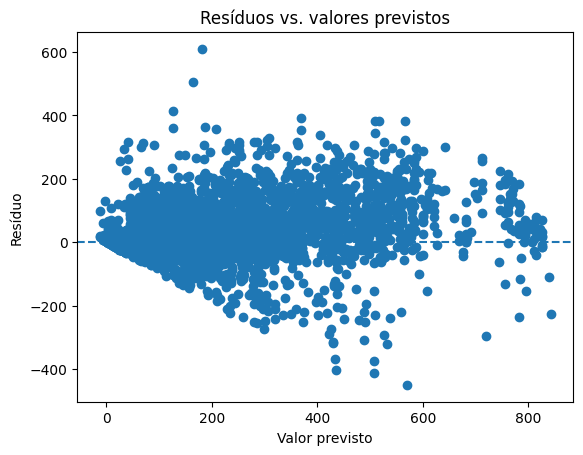

In [36]:
plt.scatter(y_pred, residuals)
plt.axhline(0, linestyle="--")
plt.title("Resíduos vs. valores previstos")
plt.xlabel("Valor previsto")
plt.ylabel("Resíduo")
plt.show()

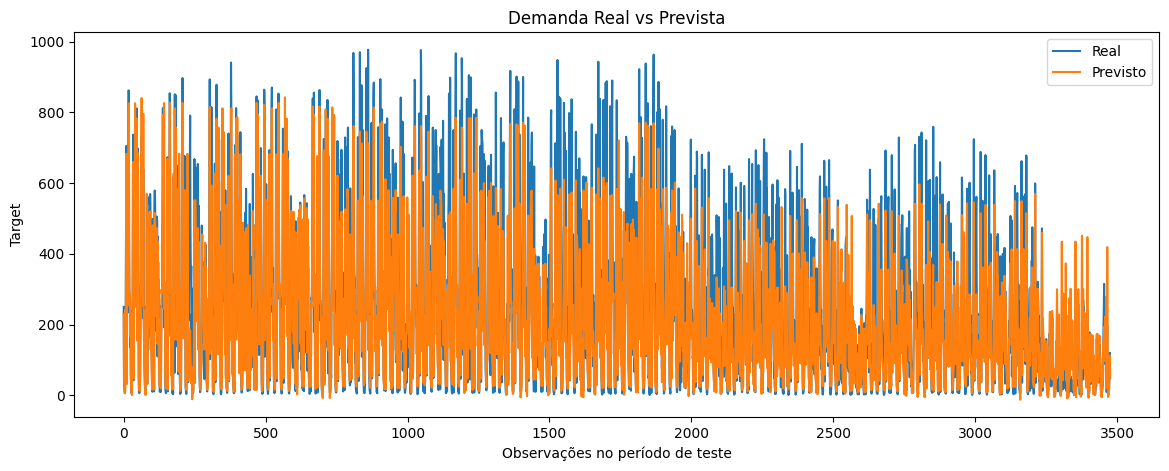

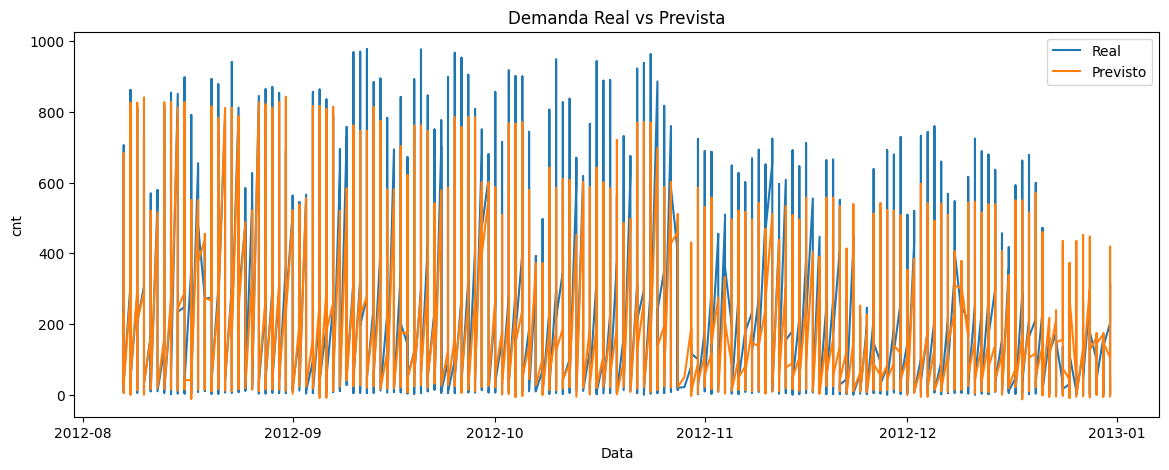

In [37]:
plt.figure(figsize=(14,5))
plt.plot(y_test.values, label="Real")
plt.plot(y_pred, label="Previsto")

plt.title("Demanda Real vs Prevista")
plt.xlabel("Observações no período de teste")
plt.ylabel("Target")
plt.legend()
plt.show()


plt.figure(figsize=(14,5))
plt.plot(test_df["dteday"], y_test, label="Real")
plt.plot(test_df["dteday"], y_pred, label="Previsto")

plt.title("Demanda Real vs Prevista")
plt.xlabel("Data")
plt.ylabel("cnt")
plt.legend()

plt.show()

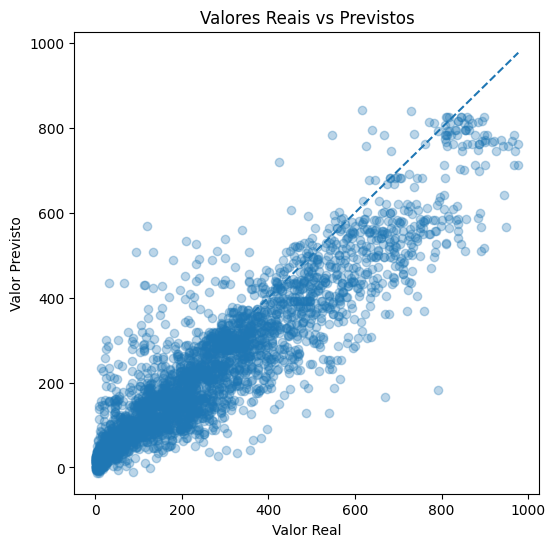

In [38]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, alpha=0.3)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Valor Real")
plt.ylabel("Valor Previsto")
plt.title("Valores Reais vs Previstos")

plt.show()

## 10.1 Análise de erros e limitações

Escreva uma análise crítica dos resultados.

**Perguntas para responder:**
- Quais tipos de erro o modelo comete mais?
- Há sinais de overfitting ou underfitting?
- A métrica escolhida captura bem o objetivo do problema?
- Há viés, limitação de dados ou risco de generalização?
- Em quais cenários o modelo não deveria ser usado?


**Resposta:**
> A avaliação final demonstra que o modelo foi capaz de reproduzir adequadamente os padrões temporais da demanda de bicicletas, acompanhando tanto os ciclos diários quanto as variações observadas ao longo do período de teste. A análise dos valores reais e previstos evidencia forte correlação entre as previsões e os valores observados.

> A análise dos resíduos indica aumento da variabilidade dos erros para demandas mais elevadas, sugerindo maior dificuldade do modelo em prever situações de pico. Ainda assim, os resultados demonstram boa capacidade de generalização e adequação do modelo para o problema proposto.

# 11. Comparação final dos modelos

Métrica principal considerada: **RMSE**


In [39]:
show_results_table(results)

,MAE,RMSE,R2,train_time_s
baseline,182.239356,249.403558,-0.282103,0.018
ElasticNet,128.043320,182.302701,0.314979,0.013
KNNRegressor,78.598101,118.373322,0.711181,0.077
XGBoost,63.517712,94.710517,0.815110,0.344
knn-orig,82.186939,122.980188,0.688263,15.969
knn-padr,82.133774,122.558659,0.690397,22.602
knn-norm,63.780207,99.780112,0.794787,21.293
XGBReg-Tuning,65.734169,95.620067,0.811541,23.954


# 12. Boas práticas e rastreabilidade

Documente decisões importantes do projeto.

**O que incluir:**
- seed utilizada;
- principais decisões de pré-processamento;
- modelos testados;
- hiperparâmetros relevantes;
- tempo aproximado de treino;
- recursos computacionais usados;
- limitações conhecidas;
- o que foi tentado e descartado.

| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| _Usar SEED = 42_ | _Garantir replicação de todo MVP_ | |
| _Usar padronização_ | _Classes desbalanceadas_ | _Equilibrar escala entre classes para modelos não baseados em árvores_ |
| _Remover coluna casual_ | _Vazamento de dados_ | _Evitar desempenho artificial_ |
| _Remover coluna registered_ | _Vazamento de dados_ | _Evitar desempenho artificial_ |
| _Transformar colunas de informações cíclicas em pares seno/cosseno_ | _Aproximar valores distantes na escala númerica padrão_ | _Melhorar captura de sazonalidade da demanda_ |
| _Realizar seleção de atributos com duas estratégias_ | _Identificar os fatores mais relevantes para o problema comparando abordagens de modelos diferentes_ | _Reduzir dimensionalidade_ |
| _Usar ElasticNet_ | _Avaliar limitações de uma abordagem linear_ | _Justificar a complexidade de uso de modelos não lineares_ |
| _Usar XGBoost_ | _Capturar não linearidades_ | _Superar baseline_ |
| _Usar KNN_ | _Capturar possível agrupamentos por estações do ano_ | _Superar baseline_ |
| _Realizar busca de hiperparâmetros para KNN e XGBoost_ | _Buscar parâmetros que otimizem os resultados dos modelos_ | _Superar resultados iniciais encontrados para ambos os modelos_ |

# 13. Conclusão

Faça o fechamento do MVP conectando o resultado ao problema inicial.

**O que incluir:**
- objetivo do trabalho;
- melhor solução encontrada;
- comparação com baseline;
- principais aprendizados;
- limitações;
- próximos passos.




**Conclusão:**  

> O crescimento das aplicações de aluguel de bicicletas amplia a importância da previsão de demanda como ferramenta de apoio à mobilidade urbana. Diferentemente de outros meios de transporte, esses sistemas geram grande volume de dados operacionais e comportamentais, possibilitando a aplicação de técnicas de Machine Learning para otimizar a distribuição dos recursos disponíveis e melhorar a experiência dos usuários.

> Neste trabalho foi desenvolvido um processo completo de análise e modelagem utilizando o Bike Sharing Dataset, com o objetivo de construir e avaliar modelos de Machine Learning capazes de prever a demanda de aluguel de bicicletas a partir de informações temporais e climáticas. Foram comparadas diferentes abordagens, incluindo um modelo baseline, modelos de regressão tradicionais e modelos mais sofisticados, além da aplicação de técnicas de engenharia de atributos, seleção de variáveis e otimização de hiperparâmetros.

> Os resultados demonstraram que o modelo XGBoost apresentou o melhor desempenho entre os modelos avaliados, alcançando RMSE de aproximadamente 94,7 e R² de 0,81. Em comparação ao baseline, que apresentou RMSE de aproximadamente 249,4 e R² negativo, e à abordagem linear com ElasticNet, com RMSE 182,3	e R² = 0,31, observa-se uma melhoria substancial na capacidade preditiva do modelo, evidenciando que os atributos temporais e climáticos possuem forte poder explicativo sobre a demanda de bicicletas e que o problema tem fortes características não lineares.

> Durante o desenvolvimento do projeto, alguns dos aprendizados obtidos foram revelados durante a análise exploratória, como a relevância dos fatores climáticos e temporais para a previsão da demanda, enquanto as etapas de engenharia de atributos mostraram a importância da representação adequada de variáveis cíclicas por meio das transformações seno e cosseno. Também foi possível observar a influência da escolha dos hiperparâmetros e das técnicas de pré-processamento sobre o desempenho dos modelos, especialmente no caso do KNN, que apresentou ganhos relevantes com a normalização ao invés da padronização dos dados para esse problema.

> As hipóteses definidas no início do trabalho foram, em grande parte, confirmadas. A primeira hipótese, de que a estação do ano influencia a demanda, foi validada, sendo observada maior ocorrência de aluguéis durante o verão, embora com distribuição relativamente equilibrada entre as demais estações. A segunda hipótese também foi confirmada, uma vez que a sensação térmica e as condições climáticas apresentaram influência significativa sobre a variável alvo, com maior demanda associada a condições climáticas mais favoráveis. Por fim, a terceira hipótese foi plenamente confirmada pela identificação de padrões cíclicos associados às horas do dia, dias da semana e meses do ano, além da presença de sazonalidade observada ao longo da série temporal.

> Apesar dos resultados positivos, algumas limitações que devem ser consideradas: O dataset contempla apenas dois anos de observações e não inclui informações como disponibilidade de bicicletas ou condições específicas da infraestrutura urbana. Além disso, restrições computacionais limitaram a exploração de espaços maiores de hiperparâmetros.

> Para os próximos passos, é válido ampliar a busca de hiperparâmetros do XGBoost e explorar não só outros modelos baseados em árvore como também modelos de maior complexidade, como redes neurais recorrentes.